# Field Time Series Visualisation
Visualise S1 backscatter, H-A-Alpha, and DpRVI with consistent colour scales across all time steps.

**Input file per field per date:** `s1_{YYYYMMDD}_{field_id}.tif` — 6 bands (float32)

| Band | Name | Original SNAP unit | Stored on disk |
|------|------|--------------------|----------------|
| 1 | VV (gamma0) | dB | dB (no change) |
| 2 | VH (gamma0) | dB | dB (no change) |
| 3 | Alpha | 0–90° | 0–1 (÷90) |
| 4 | Anisotropy | 0–1 | 0–1 (no change) |
| 5 | Entropy | 0–100 | 0–1 (no change) |
| 6 | DpRVI | 0–1 | 0–1 (no change) |

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import rasterio
import warnings
warnings.filterwarnings('ignore')

In [33]:
FIELD_ID     = 31621
DATASET_ROOT = Path('/home/johan/Thesis/Sentinel_1/ost/s1/S1_Timeseries/dataset')
FIELD_DIR    = DATASET_ROOT / 'data' / str(FIELD_ID)

# Band indices (0-indexed) in the stacked s1_{date}_{field_id}.tif
# Original SNAP units and normalisation applied by run_haalpha_timeseries.py:
#   Band 0: VV          — gamma0 backscatter, SNAP native dB,  no normalisation
#   Band 1: VH          — gamma0 backscatter, SNAP native dB,  no normalisation
#   Band 2: Alpha       — SNAP output 0-90deg, normalised /90  -> 0-1 on disk
#   Band 3: Anisotropy  — SNAP output 0-1,    no normalisation needed
#   Band 4: Entropy     — SNAP output 0-100,  normalised /100 -> 0-1 on disk
#   Band 5: DpRVI       — SNAP output 0-1,    no normalisation needed
BAND = {
    'VV':         0,
    'VH':         1,
    'Alpha':      2,
    'Anisotropy': 3,
    'Entropy':    4,
    'DpRVI':      5,
}

print(f'Field directory: {FIELD_DIR}')
print(f'Exists: {FIELD_DIR.exists()}')
print(f'S1 stacked TIFs: {sorted([f.name for f in FIELD_DIR.glob("s1_????????_*.tif")])}')

Field directory: /home/johan/Thesis/Sentinel_1/ost/s1/S1_Timeseries/dataset/data/31621
Exists: True
S1 stacked TIFs: ['s1_20240607_31621.tif', 's1_20240619_31621.tif', 's1_20240701_31621.tif', 's1_20240713_31621.tif', 's1_20240725_31621.tif', 's1_20240806_31621.tif', 's1_20240818_31621.tif', 's1_20240830_31621.tif']


In [34]:
mask_file = list(FIELD_DIR.glob('mask_*'))[0]
print(f'Loading: {mask_file.name}')
with rasterio.open(mask_file) as src:
    mask_data = src.read(1)
print(f'Mask shape: {mask_data.shape}, unique values: {np.unique(mask_data)}')
print(f'Field pixels (mask==1): {np.sum(mask_data == 1)}')

Loading: mask_31621.tif
Mask shape: (51, 41), unique values: [0 1]
Field pixels (mask==1): 1176


In [35]:
def find_stacked_s1_files(field_dir, field_id):
    """
    Discover stacked S1 TIFs written by s1_field_extraction.py.
    Pattern: s1_{YYYYMMDD}_{field_id}.tif
    Returns dict: datetime -> Path, sorted by date.
    """
    files = {}
    pattern = f's1_????????_{field_id}.tif'
    for tif in sorted(field_dir.glob(pattern)):
        parts = tif.stem.split('_')
        date_str = parts[1]
        if date_str.isdigit() and len(date_str) == 8:
            date_obj = datetime.strptime(date_str, '%Y%m%d')
            files[date_obj] = tif
            print(f'  Found: {tif.name}')
    return dict(sorted(files.items()))


def load_stacked_s1(files_dict):
    """
    Load all stacked S1 TIFs.
    Returns dict: datetime -> (6, H, W) numpy array.
    """
    data = {}
    for date, filepath in files_dict.items():
        with rasterio.open(filepath) as src:
            arr = src.read()   # (6, H, W)
            assert src.count == 6, (
                f'Expected 6 bands, got {src.count} in {filepath.name}. '
                f'Re-run s1_field_extraction.py.'
            )
        data[date] = arr
    return data


print(f'Searching for stacked S1 TIFs in {FIELD_DIR}...')
s1_files = find_stacked_s1_files(FIELD_DIR, FIELD_ID)
s1_data  = load_stacked_s1(s1_files)
print(f'\nLoaded {len(s1_data)} dates')

# Verify band ranges
# Expected: VV/VH in negative dB, all others 0-1
if s1_data:
    first = s1_data[sorted(s1_data.keys())[0]]
    band_info = [
        ('VV',         'dB (gamma0)',          'no normalisation'),
        ('VH',         'dB (gamma0)',          'no normalisation'),
        ('Alpha',      '0-90deg -> /90 -> 0-1', 'expect 0-1'),
        ('Anisotropy', '0-1 (SNAP native)',    'expect 0-1'),
        ('Entropy',    '0-100 -> /100 -> 0-1', 'expect 0-1'),
        ('DpRVI',      '0-1 (SNAP native)',    'expect 0-1'),
    ]
    print('\nBand value ranges (field pixels only):')
    for name, original, expected in band_info:
        idx  = BAND[name]
        vals = first[idx][mask_data == 1]
        print(f'  Band {idx+1} ({name:12s}): '
              f'min={np.nanmin(vals):.4f}  max={np.nanmax(vals):.4f}  '
              f'| original: {original}  | {expected}')

Searching for stacked S1 TIFs in /home/johan/Thesis/Sentinel_1/ost/s1/S1_Timeseries/dataset/data/31621...
  Found: s1_20240607_31621.tif
  Found: s1_20240619_31621.tif
  Found: s1_20240701_31621.tif
  Found: s1_20240713_31621.tif
  Found: s1_20240725_31621.tif
  Found: s1_20240806_31621.tif
  Found: s1_20240818_31621.tif
  Found: s1_20240830_31621.tif

Loaded 8 dates

Band value ranges (field pixels only):
  Band 1 (VV          ): min=-22.4563  max=-18.4571  | original: dB (gamma0)  | no normalisation
  Band 2 (VH          ): min=-17.0149  max=-9.8469  | original: dB (gamma0)  | no normalisation
  Band 3 (Alpha       ): min=0.1298  max=0.5096  | original: 0-90deg -> /90 -> 0-1  | expect 0-1
  Band 4 (Anisotropy  ): min=0.2013  max=0.8341  | original: 0-1 (SNAP native)  | expect 0-1
  Band 5 (Entropy     ): min=0.3504  max=0.9604  | original: 0-100 -> /100 -> 0-1  | expect 0-1
  Band 6 (DpRVI       ): min=0.1785  max=0.9118  | original: 0-1 (SNAP native)  | expect 0-1


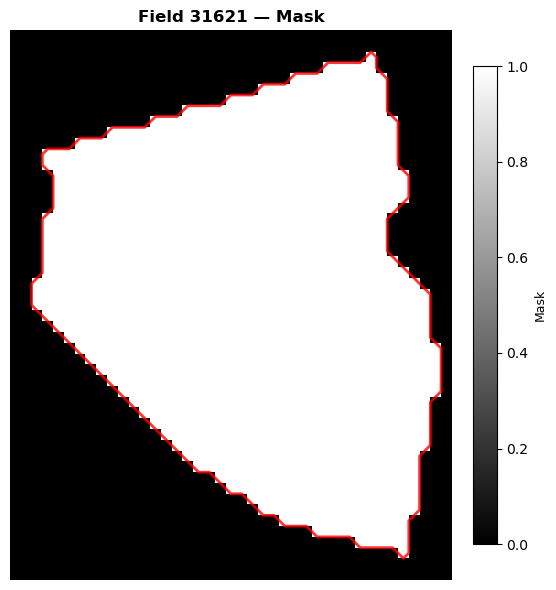

Saved: field_mask.png


In [36]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
im = ax.imshow(mask_data, cmap='gray', vmin=0, vmax=1)
ax.contour(mask_data, levels=[0.5], colors='red', linewidths=2, alpha=0.8)
ax.set_title(f'Field {FIELD_ID} — Mask', fontweight='bold', fontsize=12)
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('Mask', fontsize=9)
plt.tight_layout()
plt.savefig('field_mask.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: field_mask.png')

VV (dB, gamma0): vmin=-23.02  vmax=-17.08
VH (dB, gamma0): vmin=-16.55  vmax=-10.37


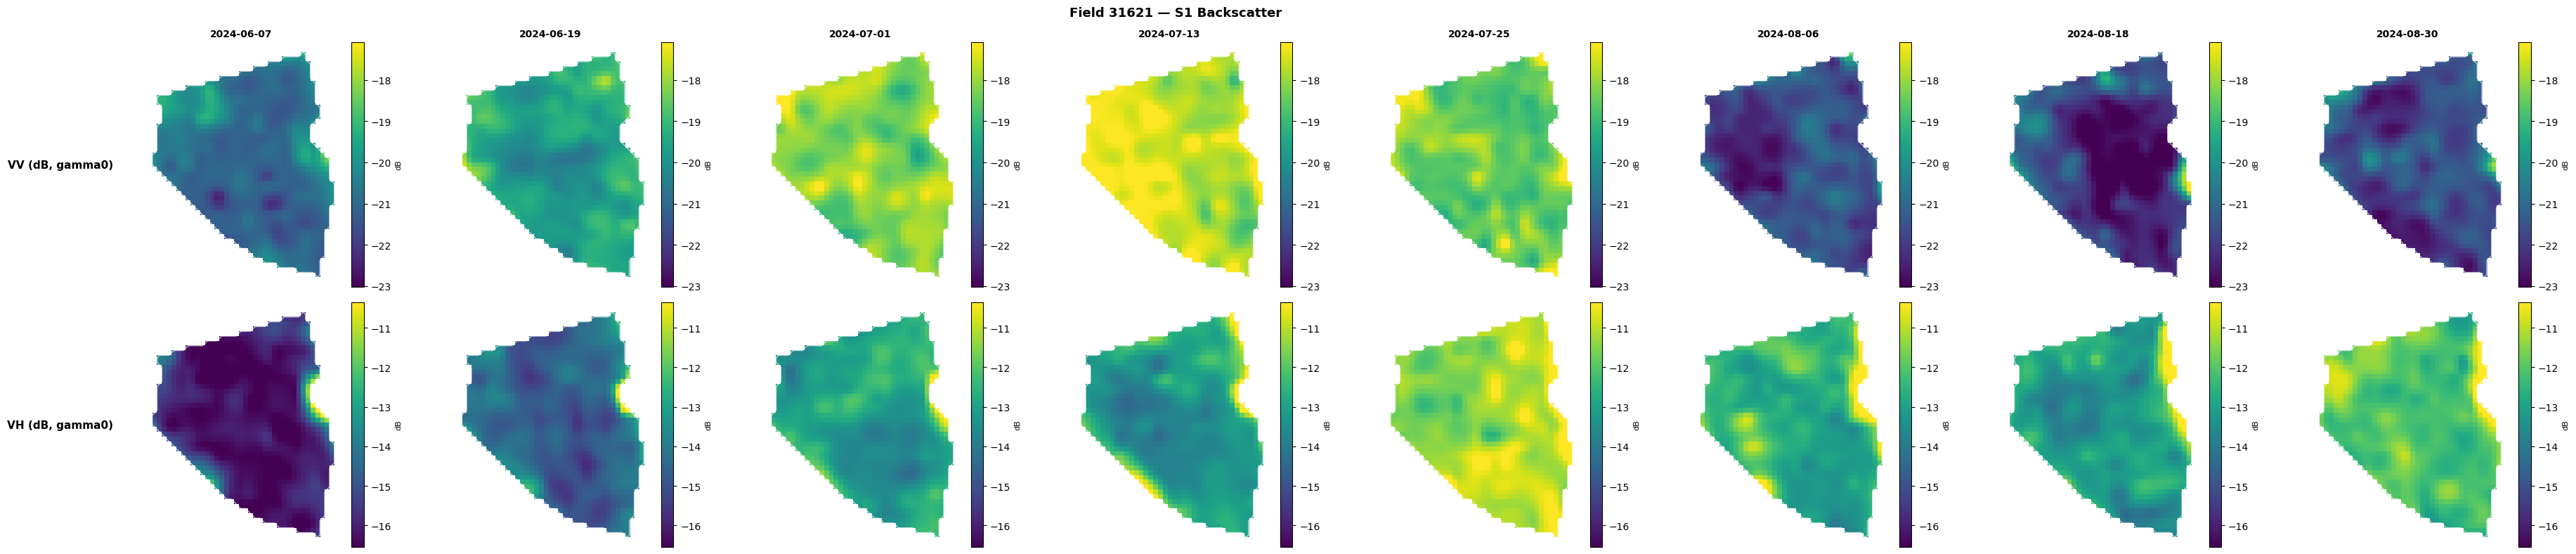

Saved: field_s1_bs.png


In [47]:
# ── S1 Backscatter — spatial maps ─────────────────────────────────────────
# Band 0=VV, 1=VH  (gamma0 dB, no normalisation)

if s1_data:
    dates       = sorted(s1_data.keys())
    n           = len(dates)
    bs_bands    = [BAND['VV'], BAND['VH']]
    band_labels = ['VV (dB, gamma0)', 'VH (dB, gamma0)']

    fig, axes = plt.subplots(2, n, figsize=(5 * n, 8))
    if n == 1:
        axes = axes.reshape(-1, 1)
    else:
        axes = axes.T

    vmins, vmaxs = [], []
    for band_idx in bs_bands:
        vals = np.concatenate([s1_data[d][band_idx][mask_data == 1] for d in dates])
        vmin, vmax = np.nanpercentile(vals, [2, 98])
        vmins.append(vmin)
        vmaxs.append(vmax)
        print(f'{band_labels[bs_bands.index(band_idx)]}: vmin={vmin:.2f}  vmax={vmax:.2f}')

    for row_idx, band_idx in enumerate(bs_bands):
        for col_idx, date in enumerate(dates):
            ax   = axes[col_idx, row_idx]
            data = np.full(s1_data[date][band_idx].shape, np.nan, dtype=float)
            data[mask_data == 1] = s1_data[date][band_idx][mask_data == 1]
            im = ax.imshow(data, cmap='viridis',
                           vmin=vmins[row_idx], vmax=vmaxs[row_idx])
            ax.contour(mask_data, levels=[0.5], colors='white', linewidths=1, alpha=0.7)
            if col_idx == 0:
                ax.text(-0.15, 0.5, band_labels[row_idx],
                        transform=ax.transAxes, fontweight='bold',
                        fontsize=11, va='center', ha='right')
            if row_idx == 0:
                ax.set_title(date.strftime('%Y-%m-%d'), fontweight='bold', fontsize=10)
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('dB', fontsize=8)

    fig.suptitle(f'Field {FIELD_ID} — S1 Backscatter',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(left=0.1)
    plt.savefig('field_s1_bs.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: field_s1_bs.png')
else:
    print('No S1 data found')

Alpha 0-90deg -> [0-1]: vmin=0.1292  vmax=0.4236
Anisotropy [0-1]: vmin=0.3163  vmax=0.8279
Entropy [0-1]: vmin=0.4154  vmax=0.9169


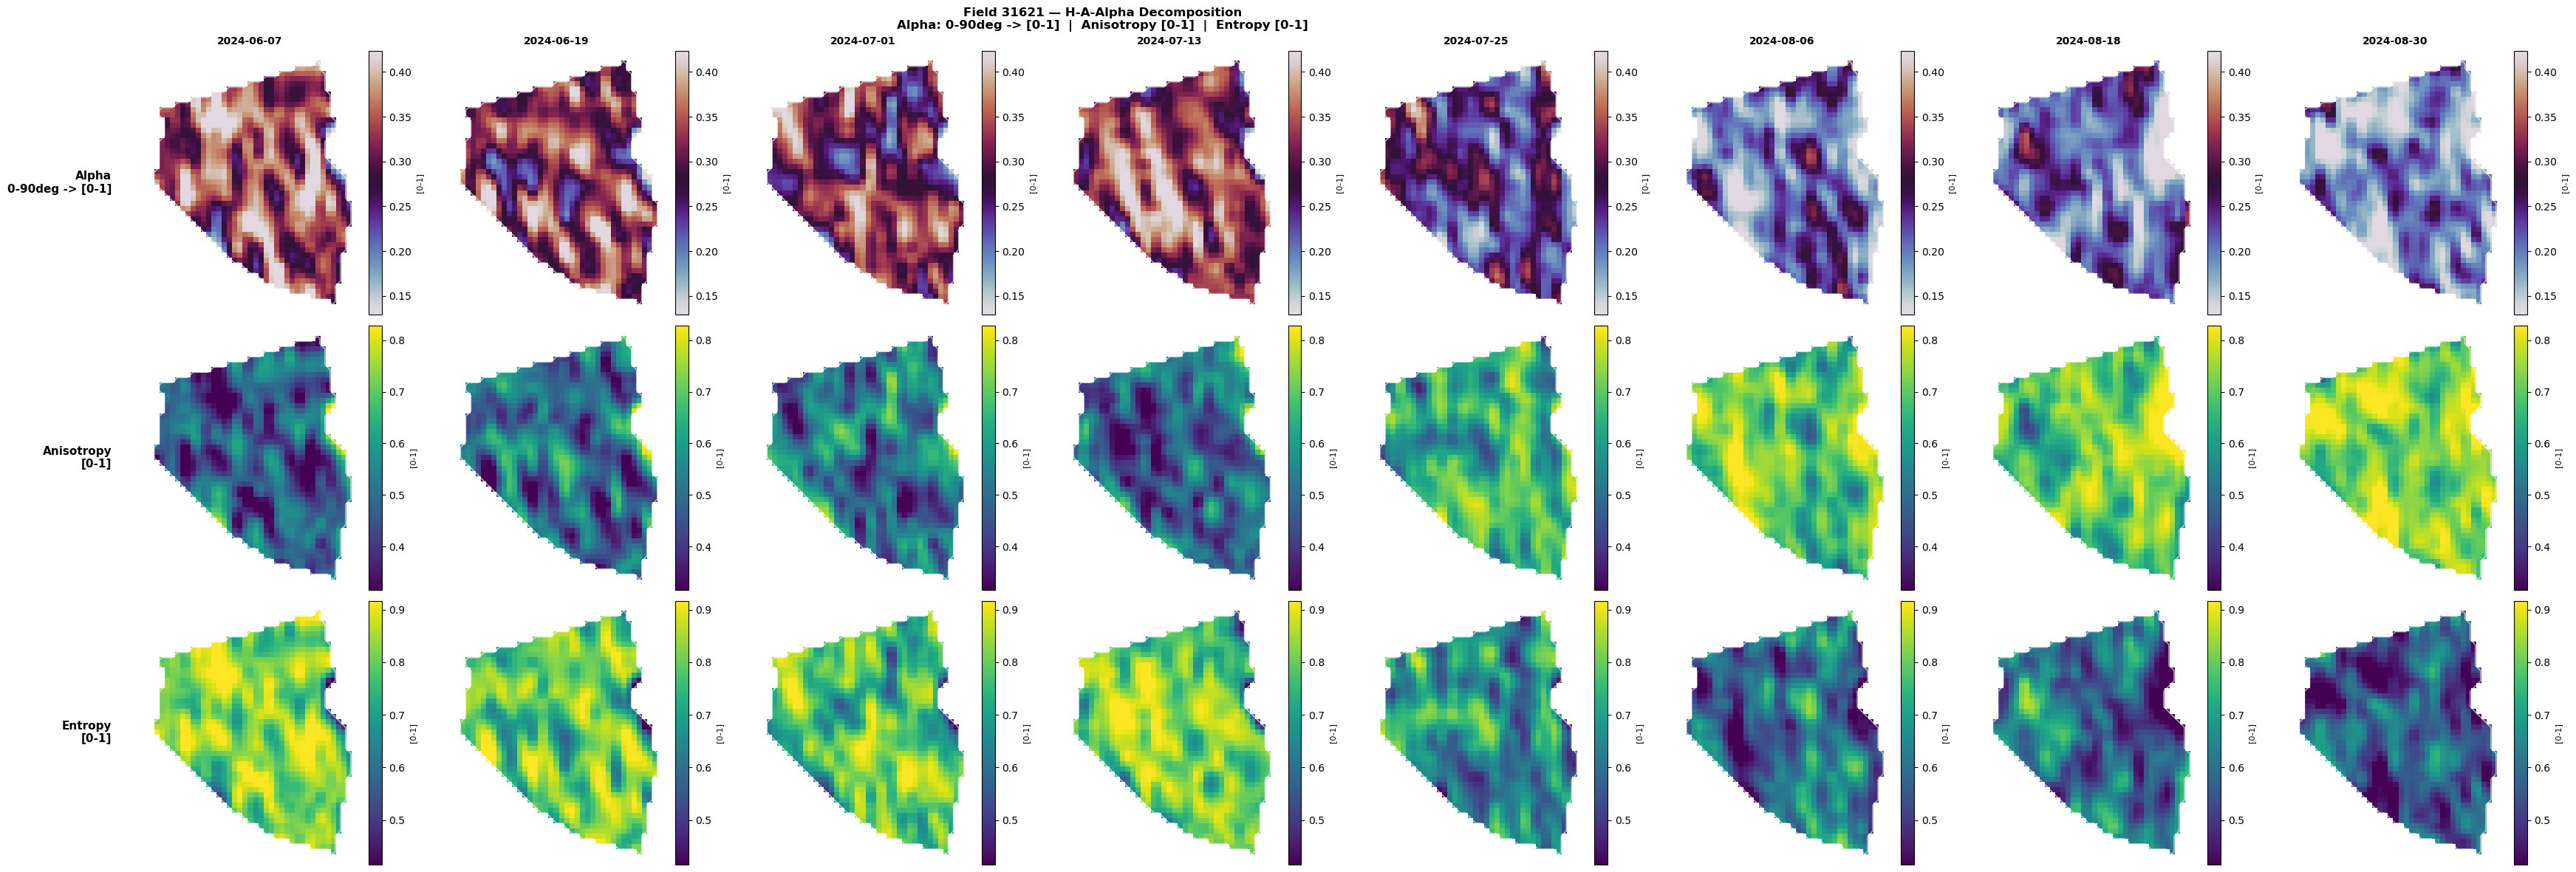

Saved: field_s1_pol.png


In [49]:
# ── H-A-Alpha — spatial maps ───────────────────────────────────────────────
# Band 2=Alpha (0-90deg -> /90 -> 0-1)
# Band 3=Anisotropy (0-1 native)
# Band 4=Entropy (0-100 -> /100 -> 0-1)

if s1_data:
    dates       = sorted(s1_data.keys())
    n           = len(dates)
    pol_bands   = [BAND['Alpha'], BAND['Anisotropy'], BAND['Entropy']]
    band_labels = [
        'Alpha\n0-90deg -> [0-1]',
        'Anisotropy\n[0-1]',
        'Entropy\n[0-1]',
    ]
    cmaps = ['twilight', 'viridis', 'viridis']

    fig, axes = plt.subplots(3, n, figsize=(5 * n, 12))
    if n == 1:
        axes = axes.reshape(-1, 1)
    else:
        axes = axes.T

    vmins, vmaxs = [], []
    for band_idx in pol_bands:
        vals = np.concatenate([s1_data[d][band_idx][mask_data == 1] for d in dates])
        vmin, vmax = np.nanpercentile(vals, [2, 98])
        vmins.append(vmin)
        vmaxs.append(vmax)
        label = band_labels[pol_bands.index(band_idx)].replace('\n', ' ')
        print(f'{label}: vmin={vmin:.4f}  vmax={vmax:.4f}')

    for row_idx, band_idx in enumerate(pol_bands):
        for col_idx, date in enumerate(dates):
            ax   = axes[col_idx, row_idx]
            data = np.full(s1_data[date][band_idx].shape, np.nan, dtype=float)
            data[mask_data == 1] = s1_data[date][band_idx][mask_data == 1]
            im = ax.imshow(data, cmap=cmaps[row_idx],
                           vmin=vmins[row_idx], vmax=vmaxs[row_idx])
            ax.contour(mask_data, levels=[0.5], colors='white', linewidths=1, alpha=0.7)
            if col_idx == 0:
                ax.text(-0.15, 0.5, band_labels[row_idx],
                        transform=ax.transAxes, fontweight='bold',
                        fontsize=11, va='center', ha='right')
            if row_idx == 0:
                ax.set_title(date.strftime('%Y-%m-%d'), fontweight='bold', fontsize=10)
            ax.axis('off')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('[0-1]', fontsize=8)

    fig.suptitle(
        f'Field {FIELD_ID} — H-A-Alpha Decomposition\n'
        f'Alpha: 0-90deg -> [0-1]  |  Anisotropy [0-1]  |  Entropy [0-1]',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.subplots_adjust(left=0.15)
    plt.savefig('field_s1_pol.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: field_s1_pol.png')
else:
    print('No S1 data found')

DpRVI (0-1 native): vmin=0.2104  vmax=0.8283


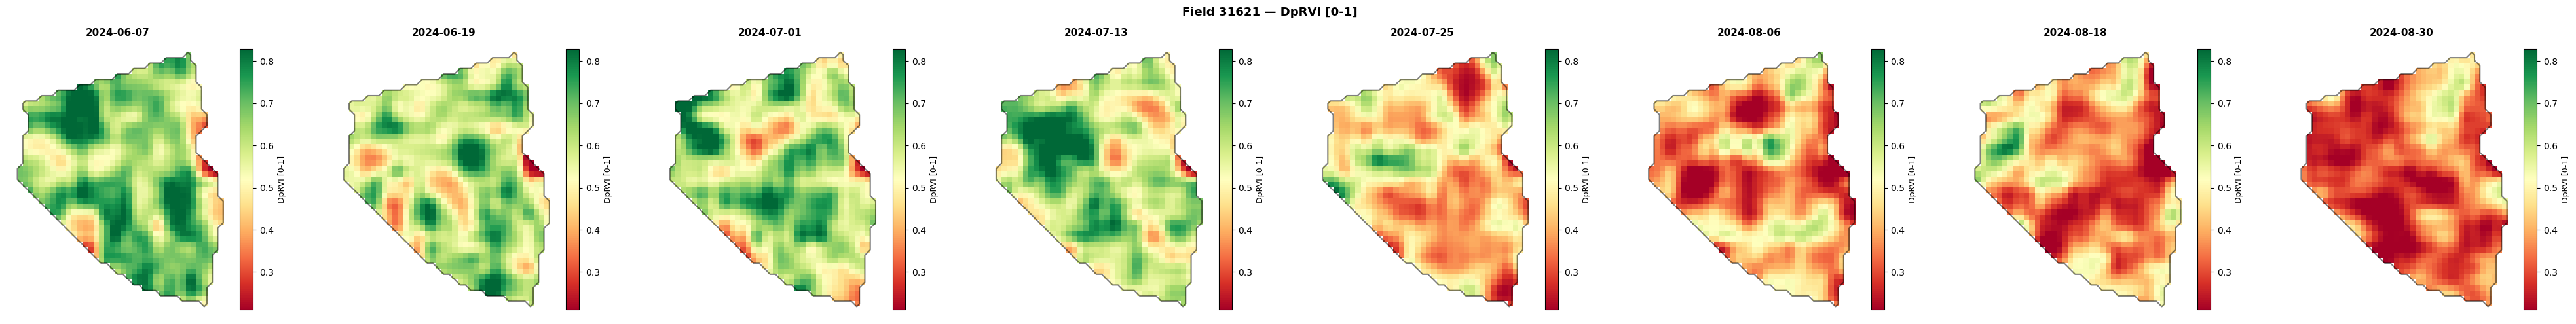

Saved: field_s1_dprvi.png


In [50]:
# ── DpRVI — spatial maps ───────────────────────────────────────────────────
# Band 5=DpRVI (0-1 native, no normalisation)

if s1_data:
    dates    = sorted(s1_data.keys())
    n        = len(dates)
    band_idx = BAND['DpRVI']

    vals = np.concatenate([s1_data[d][band_idx][mask_data == 1] for d in dates])
    vmin, vmax = np.nanpercentile(vals, [2, 98])
    print(f'DpRVI (0-1 native): vmin={vmin:.4f}  vmax={vmax:.4f}')

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    for col_idx, date in enumerate(dates):
        ax   = axes[col_idx]
        data = np.full(s1_data[date][band_idx].shape, np.nan, dtype=float)
        data[mask_data == 1] = s1_data[date][band_idx][mask_data == 1]
        im = ax.imshow(data, cmap='RdYlGn', vmin=vmin, vmax=vmax)
        ax.contour(mask_data, levels=[0.5], colors='black', linewidths=1.5, alpha=0.5)
        ax.set_title(date.strftime('%Y-%m-%d'), fontweight='bold', fontsize=11)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('DpRVI [0-1]', fontsize=9)

    fig.suptitle(f'Field {FIELD_ID} — DpRVI [0-1]',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('field_s1_dprvi.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: field_s1_dprvi.png')
else:
    print('No S1 data found')

In [40]:
# ── Per-field mean time series ─────────────────────────────────────────────
# All values read directly from stacked TIF bands — no rescaling needed.
# Column names show original SNAP unit and what was stored on disk.

dates_all = sorted(s1_data.keys())

def field_mean(band_name, dates):
    idx = BAND[band_name]
    return [np.nanmean(s1_data[d][idx][mask_data == 1]) for d in dates]

ts_vv      = field_mean('VV',         dates_all)
ts_vh      = field_mean('VH',         dates_all)
ts_alpha   = field_mean('Alpha',      dates_all)
ts_aniso   = field_mean('Anisotropy', dates_all)
ts_entropy = field_mean('Entropy',    dates_all)
ts_dprvi   = field_mean('DpRVI',      dates_all)

df_ts = pd.DataFrame({
    'Date':                        dates_all,
    'VV (dB, gamma0)':             ts_vv,
    'VH (dB, gamma0)':             ts_vh,
    'Alpha (0-90deg->0-1)':        ts_alpha,
    'Anisotropy (0-1 native)':     ts_aniso,
    'Entropy (0-100->0-1)':        ts_entropy,
    'DpRVI (0-1 native)':          ts_dprvi,
})

print('Time Series Summary (field-mean per date):')
print('=' * 110)
print(df_ts.to_string(index=False))
print('=' * 110)

csv_path = f'field_{FIELD_ID}_timeseries.csv'
df_ts.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

Time Series Summary (field-mean per date):
      Date  VV (dB, gamma0)  VH (dB, gamma0)  Alpha (0-90deg->0-1)  Anisotropy (0-1 native)  Entropy (0-100->0-1)  DpRVI (0-1 native)
2024-06-07       -20.870213       -15.978672              0.342731                 0.465697              0.819703            0.660944
2024-06-19       -19.574032       -14.488380              0.322096                 0.496822              0.793680            0.602320
2024-07-01       -18.135715       -13.017641              0.309888                 0.521122              0.775009            0.609987
2024-07-13       -17.565369       -13.127014              0.335349                 0.483207              0.807789            0.615044
2024-07-25       -18.443127       -11.163185              0.245913                 0.641663              0.661670            0.446264
2024-08-06       -21.692778       -12.551867              0.205173                 0.699576              0.594973            0.394078
2024-08-18       -2

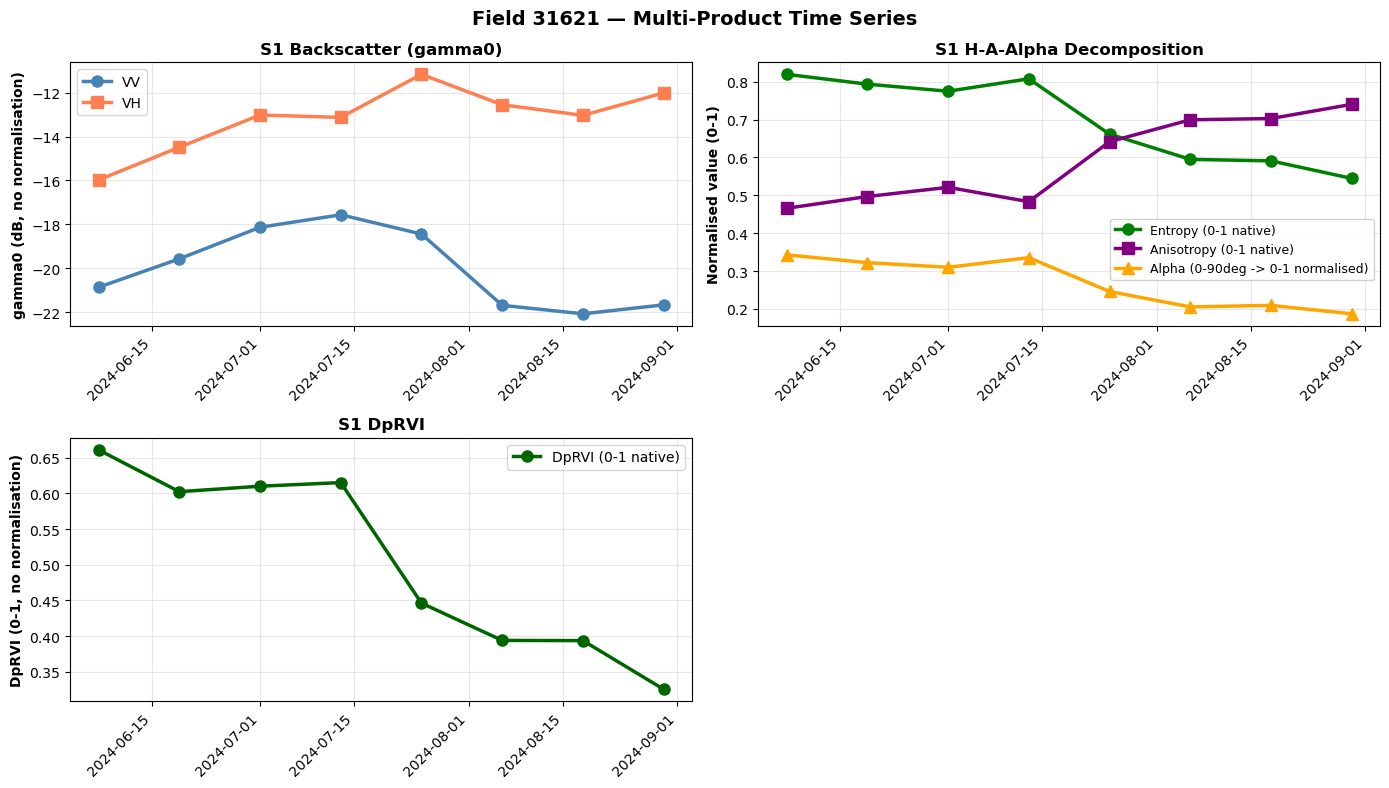

Saved: field_summary.png


In [46]:
# ── Summary time series plot ───────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Backscatter — native dB, no normalisation
axes[0,0].plot(dates_all, ts_vv, 'o-', label='VV',
               linewidth=2.5, markersize=8, color='steelblue')
axes[0,0].plot(dates_all, ts_vh, 's-', label='VH',
               linewidth=2.5, markersize=8, color='coral')
axes[0,0].set_title('S1 Backscatter (gamma0)', fontweight='bold', fontsize=12)
axes[0,0].set_ylabel('gamma0 (dB, no normalisation)', fontweight='bold', fontsize=10)
axes[0,0].legend(fontsize=10)
axes[0,0].grid(True, alpha=0.3)

# H-A-Alpha — original units shown in legend
axes[0,1].plot(dates_all, ts_entropy, 'o-', label='Entropy (0-1 native)',
               linewidth=2.5, markersize=8, color='green')
axes[0,1].plot(dates_all, ts_aniso,   's-', label='Anisotropy (0-1 native)',
               linewidth=2.5, markersize=8, color='purple')
axes[0,1].plot(dates_all, ts_alpha,   '^-', label='Alpha (0-90deg -> 0-1 normalised)',
               linewidth=2.5, markersize=8, color='orange')
axes[0,1].set_title('S1 H-A-Alpha Decomposition', fontweight='bold', fontsize=12)
axes[0,1].set_ylabel('Normalised value (0-1)', fontweight='bold', fontsize=10)
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.3)

# DpRVI — native 0-1
axes[1,0].plot(dates_all, ts_dprvi, 'o-', color='darkgreen',
               linewidth=2.5, markersize=8, label='DpRVI (0-1 native)')
axes[1,0].set_title('S1 DpRVI', fontweight='bold', fontsize=12)
axes[1,0].set_ylabel('DpRVI (0-1, no normalisation)', fontweight='bold', fontsize=10)
axes[1,0].legend(fontsize=10)
axes[0,1].legend(fontsize=9, loc='lower right', bbox_to_anchor=(1.0, 0.15), framealpha=0.9)
axes[1,0].grid(True, alpha=0.3)

axes[1,1].axis('off')

# Rotate date labels on ALL active axes individually
for ax in [axes[0,0], axes[0,1], axes[1,0]]:
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')

fig.suptitle(f'Field {FIELD_ID} — Multi-Product Time Series',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('field_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: field_summary.png')